In [47]:
import os, glob
import numpy as np
import pandas as pd
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [48]:
id="id_00"
MIMII_ROOT = rf"D:\College\TCG\data\0_dB_pump\pump\{id}"

# MIMII structure: pump/id_00/test/abnormal/*.wav
abnormal_files = sorted(glob.glob(
    os.path.join(MIMII_ROOT, "abnormal", "*.wav")
))
print(f"Found {len(abnormal_files)} abnormal samples")  # typically ~100-150

Found 143 abnormal samples


In [49]:
  # ← fix for torchcodec error
from transformers import ASTFeatureExtractor, ASTModel

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
HF_BASE   = "MIT/ast-finetuned-audioset-10-10-0.4593"
machine_id = "id_00"   # ← use a real variable name, not `id`
CKPT_PATH = rf"D:\College\TCG\AST_model\ast_finetuned\{machine_id}_ast_finetuner.pt"

feature_extractor = ASTFeatureExtractor.from_pretrained(HF_BASE)

checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)

state_dict = {
    k.replace("ast.", "", 1): v
    for k, v in checkpoint["model_state_dict"].items()
    if k.startswith("ast.")
}

ast_model = ASTModel.from_pretrained(HF_BASE)
ast_model.load_state_dict(state_dict)
ast_model = ast_model.to(DEVICE).eval()

import librosa

def extract_ast_embedding(wav_path, sr_target=16000, max_len_s=10):
    # librosa loads as float32 numpy array directly, no torchaudio needed
    wav_np, sr = librosa.load(wav_path, sr=sr_target, mono=True)

    target_len = sr_target * max_len_s
    if len(wav_np) < target_len:
        wav_np = np.pad(wav_np, (0, target_len - len(wav_np)))
    else:
        wav_np = wav_np[:target_len]

    inputs = feature_extractor(wav_np, sampling_rate=sr_target, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = ast_model(**inputs)

    cls_emb  = outputs.last_hidden_state[:, 0, :]
    mean_emb = outputs.last_hidden_state[:, 1:, :].mean(1)
    embedding = torch.cat([cls_emb, mean_emb], dim=-1)
    return embedding.squeeze().cpu().numpy()

ast_embeddings = np.array([
    extract_ast_embedding(f) for f in abnormal_files
])
np.save(f"ast_embeddings_abnormal_{id}.npy", ast_embeddings)
print(f"AST embeddings shape: {ast_embeddings.shape}")  # (N, 1536)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AST embeddings shape: (143, 1536)


In [50]:
import torch.nn as nn
class WindowEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

class WindowDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        return self.net(x)


class WindowAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = WindowEncoder()
        self.decoder = WindowDecoder()

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)

        # Safety crop (important)
        recon = recon[:, :, :x.size(2), :x.size(3)]
        return recon


In [ ]:
# Load your Chapter 3 CAE and extract bottleneck features
# Assuming your CAE was saved and has an encoder sub-network

class CAEEncoder(torch.nn.Module):
    """Strip just the encoder half from your CAE"""
    def __init__(self, full_cae):
        super().__init__()
        self.encoder = full_cae.encoder   
    
    def forward(self, x):
        return self.encoder(x)

# Audio → log-mel spectrogram (must match your CAE training config)
def wav_to_logmel(wav_path, sr=16000, n_mels=128, hop=512, n_fft=1024):
    wav_np, _ = librosa.load(wav_path, sr=sr, mono=True)
    wav_t = torch.tensor(wav_np).unsqueeze(0)  # (1, T)
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr, n_fft=n_fft, hop_length=hop, n_mels=n_mels
    )
    mel = mel_transform(wav_t)
    return torch.log(mel + 1e-9) 


cae_full = WindowAutoEncoder()
checkpoint = torch.load(rf"D:\College\TCG\Baseline_MIMII Systems\pump\best_AE_model_{id}.pth", map_location=DEVICE)
cae_full.load_state_dict(checkpoint)
cae_full = cae_full.to(DEVICE).eval()

cae_encoder = CAEEncoder(cae_full).to(DEVICE).eval()

def extract_cae_embedding(wav_path):
    logmel = wav_to_logmel(wav_path).unsqueeze(0).to(DEVICE)  # (1,1,128,T)
    with torch.no_grad():
        bottleneck = cae_encoder(logmel)
    return bottleneck.flatten().cpu().numpy()

cae_embeddings = np.array([
    extract_cae_embedding(f) for f in abnormal_files
])
np.save(f"cae_embeddings_abnormal_{id}.npy", cae_embeddings)
print(f"CAE embeddings shape: {cae_embeddings.shape}")

CAE embeddings shape: (143, 20480)


AST PCA: 1536d → 20d (95.1% variance)
CAE PCA: 20480d → 127d (95.2% variance)


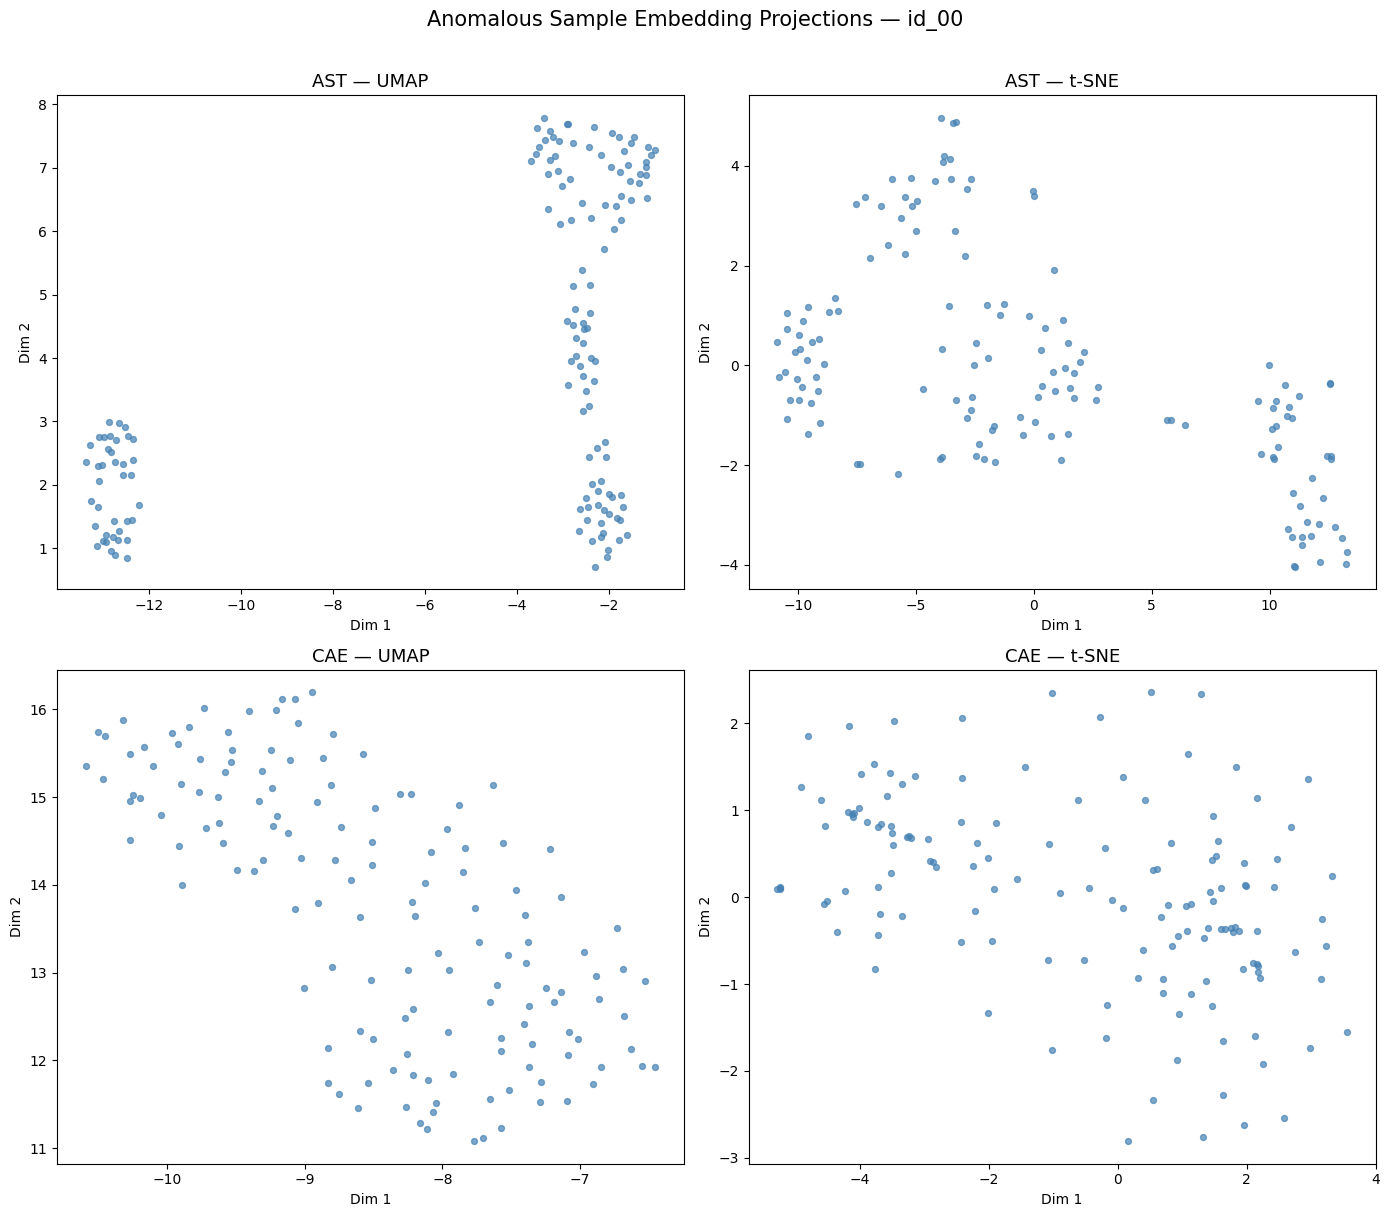

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

# ── Scale ────────────────────────────────────────────────────────────────────
scaler_ast = StandardScaler()
ast_scaled = scaler_ast.fit_transform(ast_embeddings)

scaler_cae = StandardScaler()
cae_scaled = scaler_cae.fit_transform(cae_embeddings)

# ── PCA to 95% variance ──────────────────────────────────────────────────────
pca_ast = PCA(n_components=0.95, random_state=42)
ast_pca = pca_ast.fit_transform(ast_scaled)
print(f"AST PCA: {ast_embeddings.shape[1]}d → {ast_pca.shape[1]}d "
      f"({pca_ast.explained_variance_ratio_.sum()*100:.1f}% variance)")

pca_cae = PCA(n_components=0.95, random_state=42)
cae_pca = pca_cae.fit_transform(cae_scaled)
print(f"CAE PCA: {cae_embeddings.shape[1]}d → {cae_pca.shape[1]}d "
      f"({pca_cae.explained_variance_ratio_.sum()*100:.1f}% variance)")

# ── UMAP (on PCA-reduced) ────────────────────────────────────────────────────
ast_umap = umap.UMAP(n_components=2,
                     n_neighbors=15, min_dist=0.1,n_jobs=-1).fit_transform(ast_pca)

cae_umap = umap.UMAP(n_components=2, 
                     n_neighbors=15, min_dist=0.1,n_jobs=-1).fit_transform(cae_pca)

# ── t-SNE (on PCA-reduced) ───────────────────────────────────────────────────
ast_tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                n_jobs=-1).fit_transform(ast_pca)

cae_tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                n_jobs=-1).fit_transform(cae_pca)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, proj, title in zip(
    axes.flat,
    [ast_umap, ast_tsne, cae_umap, cae_tsne],
    ["AST — UMAP", "AST — t-SNE", "CAE — UMAP", "CAE — t-SNE"]
):
    ax.scatter(proj[:, 0], proj[:, 1], s=18, alpha=0.7, c='steelblue')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

plt.suptitle(f"Anomalous Sample Embedding Projections — {machine_id}",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f"fig_embedding_projections_{machine_id}.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [55]:
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.cluster import adjusted_rand_score

def run_hdbscan(embeddings_scaled, min_cluster_size=5, min_samples=3, label=""):
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom',   # Excess of Mass — more stable
        prediction_data=True
    )
    labels = clusterer.fit_predict(embeddings_scaled)
    
    n_clusters   = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac   = (labels == -1).mean()
    stabilities  = clusterer.cluster_persistence_  # per-cluster stability
    
    # Internal validity (exclude noise points)
    mask = labels != -1
    sil  = silhouette_score(embeddings_scaled[mask], labels[mask]) if n_clusters > 1 else np.nan
    dbi  = davies_bouldin_score(embeddings_scaled[mask], labels[mask]) if n_clusters > 1 else np.nan
    
    print(f"\n[HDBSCAN — {label}]")
    print(f"  Clusters found : {n_clusters}")
    print(f"  Noise fraction : {noise_frac:.3f}")
    print(f"  Cluster stabilities: {stabilities.round(3)}")
    print(f"  Silhouette Score : {sil:.4f}")
    print(f"  Davies-Bouldin  : {dbi:.4f}")
    
    return labels, clusterer, {"n_clusters": n_clusters, "noise_frac": noise_frac,
                                "stabilities": stabilities, "silhouette": sil, "dbi": dbi}

ast_scaled,cae_scaled = ast_pca, cae_pca  # ← use PCA-reduced for clustering
hdb_ast_labels, hdb_ast, hdb_ast_metrics = run_hdbscan(ast_scaled, label="AST")
hdb_cae_labels, hdb_cae, hdb_cae_metrics = run_hdbscan(cae_scaled, label="CAE")


[HDBSCAN — AST]
  Clusters found : 3
  Noise fraction : 0.035
  Cluster stabilities: [0.162 0.176 0.108]
  Silhouette Score : 0.4058
  Davies-Bouldin  : 1.0266

[HDBSCAN — CAE]
  Clusters found : 2
  Noise fraction : 0.916
  Cluster stabilities: [0.251 0.013]
  Silhouette Score : 0.3973
  Davies-Bouldin  : 0.9266


In [56]:
# Compare cluster assignments on the same samples
# Points labelled -1 (noise) by either method complicate ARI — two options:
# Option A: exclude noise from both sides (conservative, cleaner)
# Option B: treat -1 as its own cluster (inclusive)

def cross_embedding_ari(labels_a, labels_b, exclude_noise=True):
    if exclude_noise:
        mask = (labels_a != -1) & (labels_b != -1)
        la, lb = labels_a[mask], labels_b[mask]
        n_excluded = (~mask).sum()
        print(f"  Samples excluded (noise in either): {n_excluded}")
    else:
        la, lb = labels_a, labels_b
    ari = adjusted_rand_score(la, lb)
    print(f"  Cross-embedding ARI: {ari:.4f}")
    return ari

ari_hdbscan = cross_embedding_ari(hdb_ast_labels, hdb_cae_labels)

  Samples excluded (noise in either): 131
  Cross-embedding ARI: 0.0680


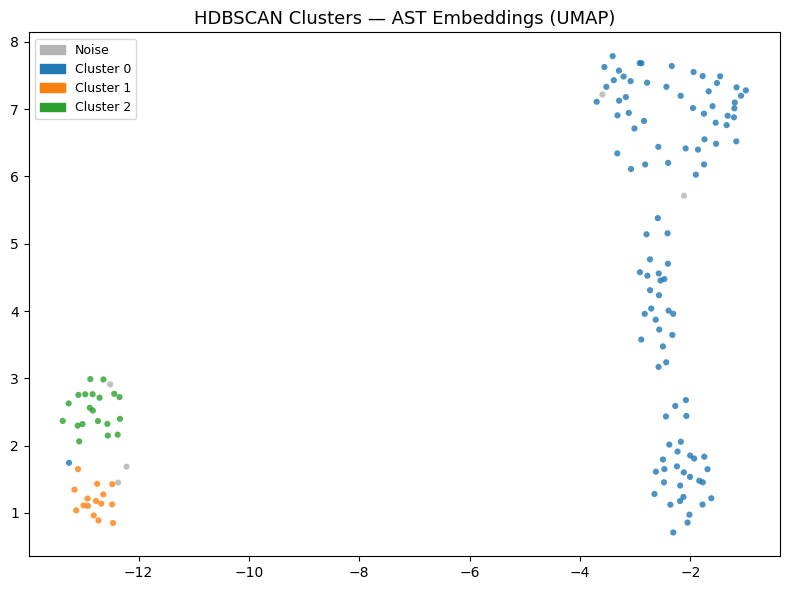

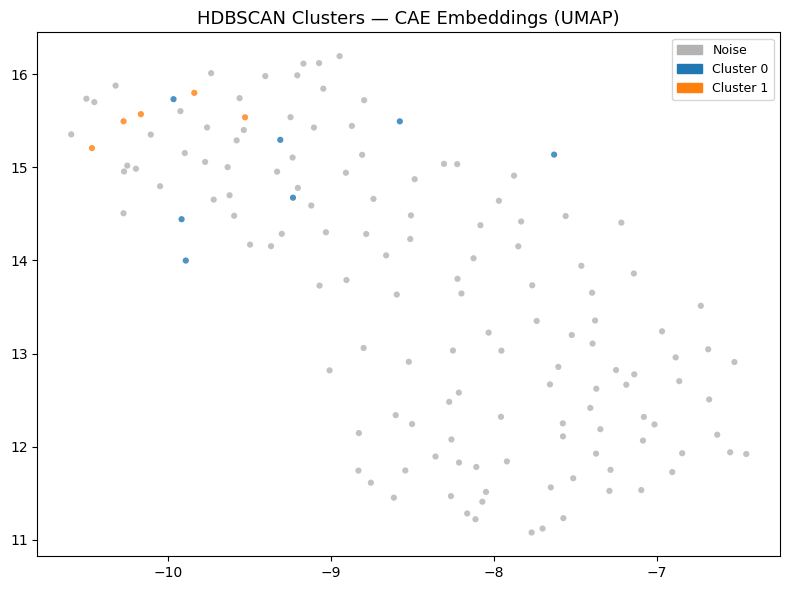

In [57]:
def plot_hdbscan_clusters(projection, labels, title, save_path):
    palette = sns.color_palette("tab10", n_colors=len(set(labels))-1)
    color_map = {-1: (0.7, 0.7, 0.7)}   # noise → grey
    for i, c in enumerate(sorted(set(labels) - {-1})):
        color_map[c] = palette[i]
    
    colors = [color_map[l] for l in labels]
    plt.figure(figsize=(8, 6))
    plt.scatter(projection[:, 0], projection[:, 1],
                c=colors, s=20, alpha=0.8, edgecolors='none')
    
    # Legend
    from matplotlib.patches import Patch
    handles = [Patch(color=color_map[c], label=f"Cluster {c}" if c != -1 else "Noise")
               for c in sorted(color_map)]
    plt.legend(handles=handles, fontsize=9)
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_hdbscan_clusters(ast_umap, hdb_ast_labels,
    "HDBSCAN Clusters — AST Embeddings (UMAP)", "fig_hdbscan_ast.pdf")
plot_hdbscan_clusters(cae_umap, hdb_cae_labels,
    "HDBSCAN Clusters — CAE Embeddings (UMAP)", "fig_hdbscan_cae.pdf")

In [58]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class DECAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 64]):
        super().__init__()
        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        self.encoder = nn.Sequential(*enc_layers)
        
        # Decoder (mirror)
        dec_layers = []
        for h in reversed(hidden_dims[:-1]):
            dec_layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        dec_layers += [nn.Linear(prev, input_dim)]
        self.decoder = nn.Sequential(*dec_layers)
    
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat

class DECClusteringLayer(nn.Module):
    """Student t-distribution soft assignments"""
    def __init__(self, n_clusters, embedding_dim, alpha=1.0):
        super().__init__()
        self.centroids = nn.Parameter(torch.randn(n_clusters, embedding_dim))
        self.alpha = alpha
    
    def forward(self, z):
        # q_ij: soft assignment probability
        diff = z.unsqueeze(1) - self.centroids.unsqueeze(0)   # (N, K, D)
        dist = (diff ** 2).sum(-1)                             # (N, K)
        q = (1 + dist / self.alpha) ** (-(self.alpha + 1) / 2)
        q = q / q.sum(dim=1, keepdim=True)
        return q

  k=2: gen_error=25.5744 ± 1.0079
  k=3: gen_error=19.7540 ± 1.1057
  k=4: gen_error=17.8182 ± 1.1676
  k=5: gen_error=16.7596 ± 0.9197
  k=6: gen_error=16.2030 ± 1.1501
  k=7: gen_error=15.8036 ± 1.4199
  k=8: gen_error=15.7084 ± 1.2115


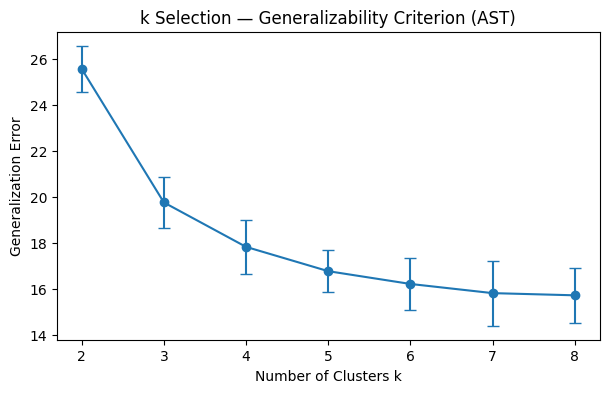

  k=2: gen_error=121.4238 ± 3.6307
  k=3: gen_error=121.4044 ± 3.3072
  k=4: gen_error=121.5862 ± 3.9821
  k=5: gen_error=122.1714 ± 4.2741
  k=6: gen_error=122.1907 ± 3.3426
  k=7: gen_error=123.1045 ± 3.3282
  k=8: gen_error=123.4912 ± 6.0249


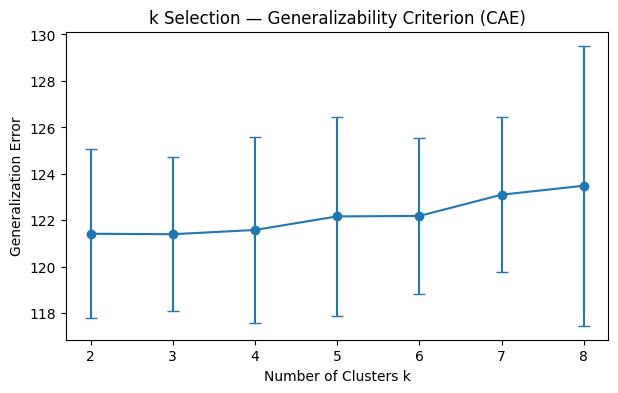

Optimal k* for AST: 4


In [59]:
from sklearn.cluster import KMeans

def generalizability_score(embeddings, k, n_bootstrap=20, held_out_frac=0.2):
    """
    For a given k, train KMeans on 80% of embeddings n_bootstrap times.
    Score = mean reconstruction error on held-out 20% (how well centroids
    trained on one subset explain unseen points).
    Lower = more generalizable cluster structure for this k.
    """
    N = len(embeddings)
    held_out_n = int(N * held_out_frac)
    errors = []
    
    for _ in range(n_bootstrap):
        idx = np.random.permutation(N)
        train_idx, test_idx = idx[held_out_n:], idx[:held_out_n]
        
        km = KMeans(n_clusters=k, n_init=5, random_state=None)
        km.fit(embeddings[train_idx])
        
        # For held-out points: assign to nearest centroid, measure distance
        test_emb = embeddings[test_idx]
        dists = np.min(
            np.linalg.norm(test_emb[:, None, :] - km.cluster_centers_[None, :, :], axis=-1),
            axis=1
        )
        errors.append(dists.mean())
    
    return np.mean(errors), np.std(errors)

# Test k = 2..8 on both embedding types
k_range = range(2, 9)

for emb, name in [(ast_scaled, "AST"), (cae_scaled, "CAE")]:
    scores, stds = [], []
    for k in k_range:
        mean_err, std_err = generalizability_score(emb, k)
        scores.append(mean_err); stds.append(std_err)
        print(f"  k={k}: gen_error={mean_err:.4f} ± {std_err:.4f}")
    
    plt.figure(figsize=(7, 4))
    plt.errorbar(list(k_range), scores, yerr=stds, marker='o', capsize=4)
    plt.xlabel("Number of Clusters k"); plt.ylabel("Generalization Error")
    plt.title(f"k Selection — Generalizability Criterion ({name})")
    plt.xticks(list(k_range))
    plt.savefig(f"fig_k_selection_{name.lower()}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Pick k* = elbow of the generalizability curve (use knee detection)
from kneed import KneeLocator   # pip install kneed

scores_ast = [generalizability_score(ast_scaled, k)[0] for k in k_range]
knee = KneeLocator(list(k_range), scores_ast, curve='convex', direction='decreasing')
k_star_ast = knee.knee
print(f"Optimal k* for AST: {k_star_ast}")

In [60]:
def train_dec(embeddings, k, n_epochs_pretrain=100, n_epochs_cluster=150,
              batch_size=32, lr=1e-3, device=DEVICE):
    
    X = torch.FloatTensor(embeddings).to(device)
    input_dim = X.shape[1]
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)
    
    # --- Phase 1: Pretrain autoencoder ---
    ae = DECAutoencoder(input_dim, hidden_dims=[512, 256, 64]).to(device)
    opt = torch.optim.Adam(ae.parameters(), lr=lr)
    
    for epoch in range(n_epochs_pretrain):
        ae.train()
        total_loss = 0
        for (xb,) in loader:
            z, x_hat = ae(xb)
            loss = F.mse_loss(x_hat, xb)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item()
        if (epoch + 1) % 20 == 0:
            print(f"  Pretrain epoch {epoch+1}/{n_epochs_pretrain}, loss={total_loss/len(loader):.4f}")
    
    # --- Initialize centroids with k-means on pretrained embeddings ---
    ae.eval()
    with torch.no_grad():
        Z_init = ae.encoder(X).cpu().numpy()
    km_init = KMeans(n_clusters=k, n_init=20, random_state=42)
    km_init.fit(Z_init)
    
    cluster_layer = DECClusteringLayer(k, 64).to(device)
    cluster_layer.centroids.data = torch.FloatTensor(km_init.cluster_centers_).to(device)
    
    # --- Phase 2: Joint clustering optimization ---
    all_params = list(ae.parameters()) + list(cluster_layer.parameters())
    opt2 = torch.optim.Adam(all_params, lr=lr * 0.1)
    
    def target_distribution(q):
        """Sharpen assignments: p_ij = (q_ij^2 / sum_i q_ij) / sum_j (...)"""
        f = q.sum(0)
        p = (q ** 2) / f
        return (p.T / p.sum(1)).T
    
    for epoch in range(n_epochs_cluster):
        ae.train(); cluster_layer.train()
        
        # Recompute target distribution every 5 epochs
        if epoch % 5 == 0:
            ae.eval(); cluster_layer.eval()
            with torch.no_grad():
                Z_full, _ = ae(X)
                Q_full = cluster_layer(Z_full)
                P_full = target_distribution(Q_full).detach()
            ae.train(); cluster_layer.train()
        
        total_loss = 0
        for i, (xb,_) in enumerate(DataLoader(TensorDataset(X, P_full),
                                             batch_size=batch_size, shuffle=False)):
            xb_data, pb = xb if isinstance(xb, list) else (xb, P_full[i*batch_size:(i+1)*batch_size])
            break  # fix indexing — simpler full-batch for small N
        
        # Full-batch update (anomalies are typically <200 samples, fits in memory)
        Z, X_hat = ae(X)
        Q = cluster_layer(Z)
        
        loss_cluster = F.kl_div(Q.log(), P_full, reduction='batchmean')
        loss_recon   = F.mse_loss(X_hat, X)
        loss = loss_cluster + 0.1 * loss_recon
        
        opt2.zero_grad(); loss.backward(); opt2.step()
        
        if (epoch + 1) % 30 == 0:
            print(f"  Cluster epoch {epoch+1}/{n_epochs_cluster}, loss={loss.item():.4f}")
    
    # Final assignments
    ae.eval(); cluster_layer.eval()
    with torch.no_grad():
        Z_final, _ = ae(X)
        Q_final = cluster_layer(Z_final)
        dec_labels = Q_final.argmax(dim=1).cpu().numpy()
    
    return dec_labels, ae, cluster_layer, Z_final.cpu().numpy()

# Run DEC with k* found above
dec_ast_labels, _, _, Z_ast_dec = train_dec(ast_scaled, k=k_star_ast)
print("="*30)
dec_cae_labels, _, _, Z_cae_dec = train_dec(cae_scaled, k=k_star_ast)  # or use k* from CAE curve

  Pretrain epoch 20/100, loss=9.5542
  Pretrain epoch 40/100, loss=4.8931
  Pretrain epoch 60/100, loss=3.3196
  Pretrain epoch 80/100, loss=3.5991
  Pretrain epoch 100/100, loss=2.4300
  Cluster epoch 30/150, loss=0.1528
  Cluster epoch 60/150, loss=0.1510
  Cluster epoch 90/150, loss=0.1431
  Cluster epoch 120/150, loss=0.1316
  Cluster epoch 150/150, loss=0.1212
  Pretrain epoch 20/100, loss=104.0605
  Pretrain epoch 40/100, loss=79.7910
  Pretrain epoch 60/100, loss=61.6656
  Pretrain epoch 80/100, loss=43.5344
  Pretrain epoch 100/100, loss=31.3165
  Cluster epoch 30/150, loss=1.9724
  Cluster epoch 60/150, loss=1.8165
  Cluster epoch 90/150, loss=1.6796
  Cluster epoch 120/150, loss=1.5533
  Cluster epoch 150/150, loss=1.4352


In [61]:
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score

def method_agreement_table(hdb_labels, dec_labels, emb_name):
    # Exclude HDBSCAN noise from both comparisons
    mask = hdb_labels != -1
    hl, dl = hdb_labels[mask], dec_labels[mask]
    
    ari  = adjusted_rand_score(hl, dl)
    nmi  = normalized_mutual_info_score(hl, dl)
    k_hdb = len(set(hl))
    k_dec = len(set(dl))
    
    print(f"\n[{emb_name}] HDBSCAN vs DEC Agreement")
    print(f"  HDBSCAN k : {k_hdb}")
    print(f"  DEC k     : {k_dec}")
    print(f"  ARI       : {ari:.4f}")
    print(f"  NMI       : {nmi:.4f}")
    return {"embedding": emb_name, "k_hdbscan": k_hdb, "k_dec": k_dec,
            "ARI": round(ari, 4), "NMI": round(nmi, 4)}

rows = [
    method_agreement_table(hdb_ast_labels, dec_ast_labels, "AST"),
    method_agreement_table(hdb_cae_labels, dec_cae_labels, "CAE"),
]
df_agreement = pd.DataFrame(rows)
print("\n", df_agreement.to_string(index=False))

# Also cross-method cross-embedding ARI
ari_cross = adjusted_rand_score(
    dec_ast_labels,
    dec_cae_labels
)
print(f"\nCross-embedding DEC ARI (AST vs CAE): {ari_cross:.4f}")


[AST] HDBSCAN vs DEC Agreement
  HDBSCAN k : 3
  DEC k     : 4
  ARI       : 0.2515
  NMI       : 0.5047

[CAE] HDBSCAN vs DEC Agreement
  HDBSCAN k : 2
  DEC k     : 1
  ARI       : 0.0000
  NMI       : 0.0000

 embedding  k_hdbscan  k_dec    ARI    NMI
      AST          3      4 0.2515 0.5047
      CAE          2      1 0.0000 0.0000

Cross-embedding DEC ARI (AST vs CAE): 0.2214


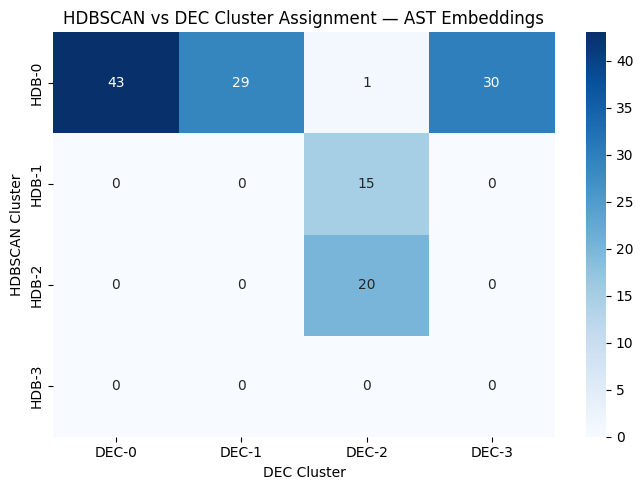

In [62]:
# Confusion-style heatmap between HDBSCAN and DEC assignments (AST)
from sklearn.metrics import confusion_matrix

mask = hdb_ast_labels != -1
cm = confusion_matrix(hdb_ast_labels[mask], dec_ast_labels[mask])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"DEC-{i}" for i in range(cm.shape[1])],
            yticklabels=[f"HDB-{i}" for i in range(cm.shape[0])])
plt.title("HDBSCAN vs DEC Cluster Assignment — AST Embeddings")
plt.ylabel("HDBSCAN Cluster"); plt.xlabel("DEC Cluster")
plt.tight_layout()
plt.savefig("fig_agreement_heatmap_ast.pdf", dpi=300, bbox_inches='tight')
plt.show()


Cluster 0: 103 samples


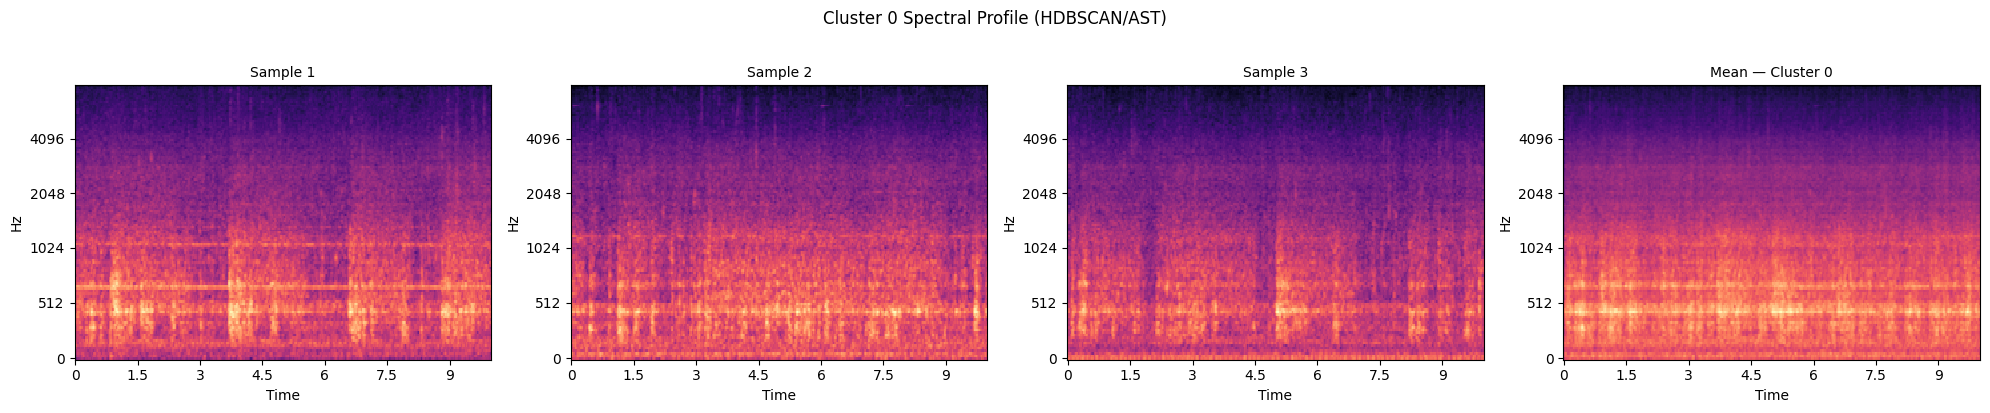


Cluster 1: 15 samples


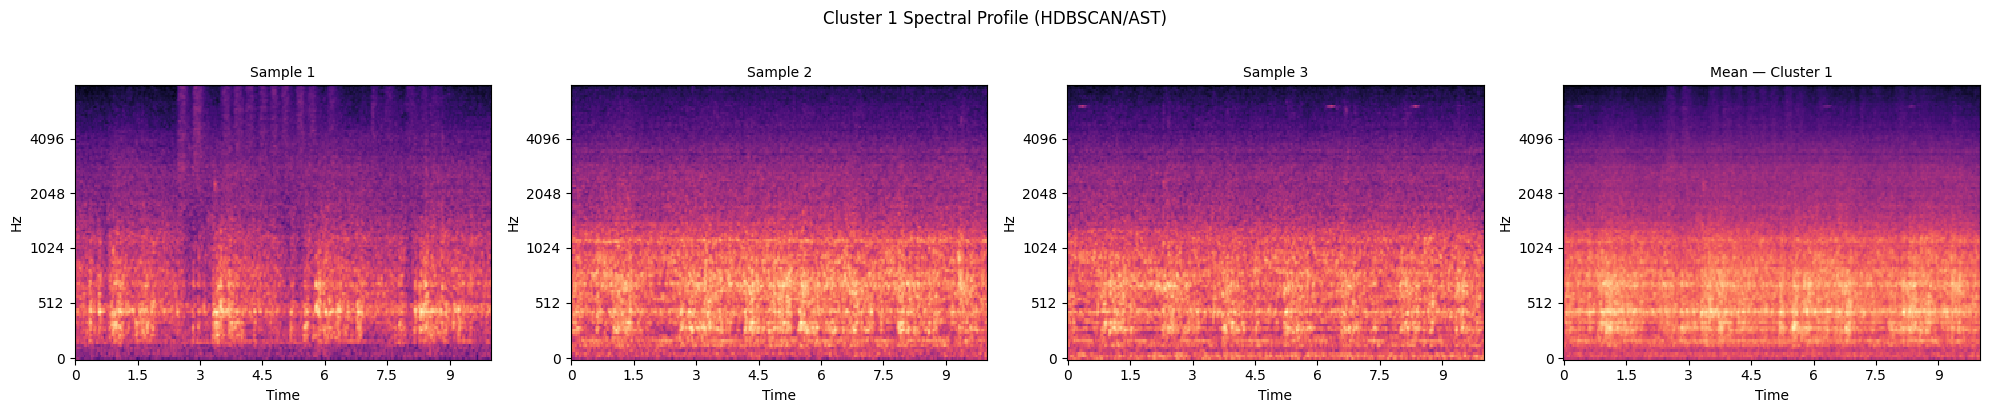


Cluster 2: 20 samples


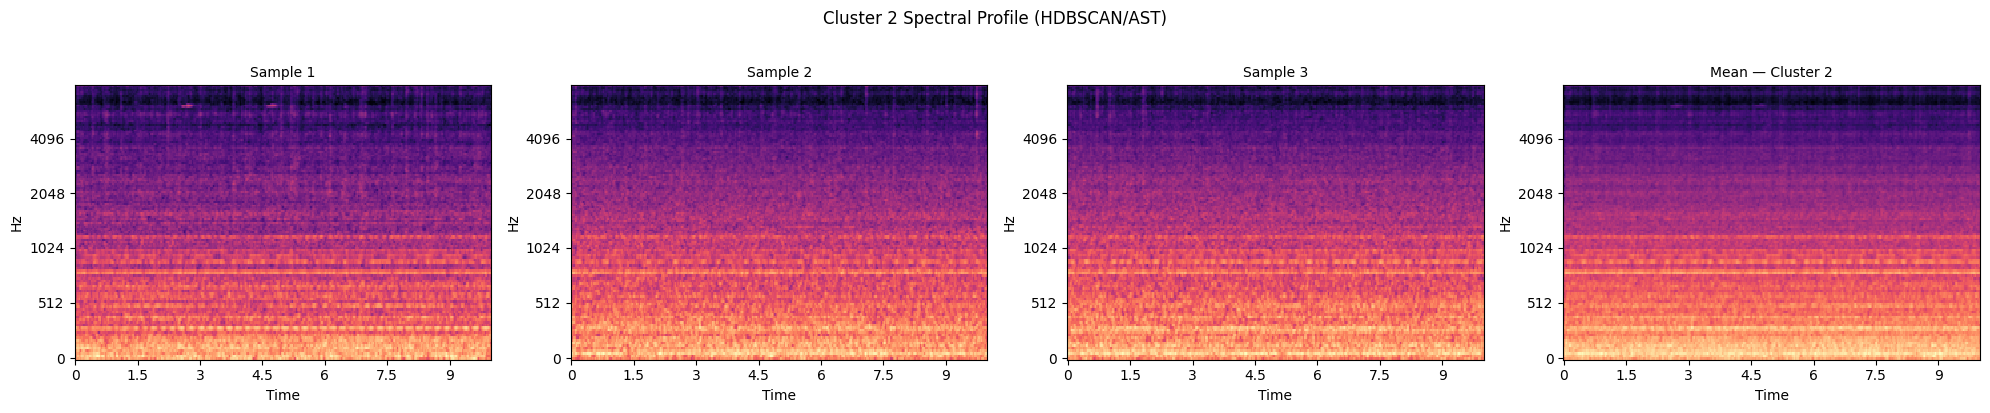

In [63]:
import librosa, librosa.display

def cluster_acoustic_summary(file_list, labels, cluster_id, n_examples=3):
    """
    For a given cluster, plot mean mel-spectrogram of its members
    and report duration + basic spectral stats.
    """
    member_files = [f for f, l in zip(file_list, labels) if l == cluster_id]
    print(f"\nCluster {cluster_id}: {len(member_files)} samples")
    
    spectrograms = []
    for fp in member_files[:n_examples]:
        y, sr = librosa.load(fp, sr=16000)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max)
        spectrograms.append(S_db)
    
    mean_spec = np.mean(spectrograms, axis=0)
    
    fig, axes = plt.subplots(1, n_examples + 1, figsize=(5 * (n_examples + 1), 4))
    for i, (fp, spec) in enumerate(zip(member_files[:n_examples], spectrograms)):
        librosa.display.specshow(spec, sr=16000, hop_length=512,
                                  x_axis='time', y_axis='mel', ax=axes[i])
        axes[i].set_title(f"Sample {i+1}", fontsize=10)
    
    librosa.display.specshow(mean_spec, sr=16000, hop_length=512,
                              x_axis='time', y_axis='mel', ax=axes[-1])
    axes[-1].set_title(f"Mean — Cluster {cluster_id}", fontsize=10)
    plt.suptitle(f"Cluster {cluster_id} Spectral Profile (HDBSCAN/AST)", y=1.02)
    plt.tight_layout()
    plt.savefig(f"fig_cluster{cluster_id}_spectrogram.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Run for each discovered cluster
for cid in sorted(set(hdb_ast_labels)):
    if cid == -1:
        continue
    cluster_acoustic_summary(abnormal_files, hdb_ast_labels, cid)

In [64]:
def spectral_stats_per_cluster(file_list, labels):
    records = []
    for fp, label in zip(file_list, labels):
        if label == -1:
            continue
        y, sr = librosa.load(fp, sr=16000)
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
        rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
        rms       = librosa.feature.rms(y=y).mean()
        records.append({
            "cluster": label,
            "centroid_hz": centroid,
            "bandwidth_hz": bandwidth,
            "rolloff_hz": rolloff,
            "rms": rms
        })
    
    df = pd.DataFrame(records)
    summary = df.groupby("cluster").agg(["mean", "std"]).round(2)
    print(summary)
    summary.to_csv("cluster_spectral_stats.csv")
    return summary

spectral_summary = spectral_stats_per_cluster(abnormal_files, hdb_ast_labels)

        centroid_hz         bandwidth_hz         rolloff_hz           rms     
               mean     std         mean     std       mean     std  mean  std
cluster                                                                       
0           1652.85  222.96      1755.52  124.56    3433.22  465.06  0.01  0.0
1           1426.88  106.95      1532.29   82.48    2788.68  268.29  0.01  0.0
2           1353.75  171.45      1668.31  190.27    2832.52  452.13  0.01  0.0


In [65]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# After your existing DEC training calls:
# dec_ast_labels, dec_ast_ae, dec_ast_cl = train_dec(ast_scaled, k=k_star_ast)
# dec_cae_labels, dec_cae_ae, dec_cae_cl = train_dec(cae_scaled, k=1)

# ── DEC internal validity scores ─────────────────────────────────────────────
def dec_validity_scores(embeddings, labels, name):
    n_clusters = len(set(labels))
    if n_clusters < 2:
        print(f"\n[DEC — {name}] Only {n_clusters} cluster — silhouette undefined")
        return {"silhouette": np.nan, "dbi": np.nan}
    
    sil = silhouette_score(embeddings, labels)
    dbi = davies_bouldin_score(embeddings, labels)
    print(f"\n[DEC — {name}]")
    print(f"  Clusters found : {n_clusters}")
    print(f"  Silhouette Score : {sil:.4f}")
    print(f"  Davies-Bouldin  : {dbi:.4f}")
    return {"silhouette": sil, "dbi": dbi}

dec_ast_metrics = dec_validity_scores(ast_scaled, dec_ast_labels, "AST")
dec_cae_metrics = dec_validity_scores(cae_scaled, dec_cae_labels, "CAE")


[DEC — AST]
  Clusters found : 4
  Silhouette Score : 0.3872
  Davies-Bouldin  : 1.0325

[DEC — CAE]
  Clusters found : 4
  Silhouette Score : 0.0596
  Davies-Bouldin  : 5.1139


In [66]:
summary = pd.DataFrame({
    "Method":     ["HDBSCAN", "DEC"],
    "AST — k":    [hdb_ast_metrics["n_clusters"], len(set(dec_ast_labels))],
    "AST — Sil":  [hdb_ast_metrics["silhouette"], dec_ast_metrics["silhouette"]],
    "AST — DBI":  [hdb_ast_metrics["dbi"],        dec_ast_metrics["dbi"]],
    "CAE — k":    [hdb_cae_metrics["n_clusters"], len(set(dec_cae_labels))],
    "CAE — Sil":  [hdb_cae_metrics["silhouette"], dec_cae_metrics["silhouette"]],
    "CAE — DBI":  [hdb_cae_metrics["dbi"],        dec_cae_metrics["dbi"]],
})
print(summary.to_string(index=False))
summary.to_csv("table_clustering_validity.csv", index=False)

 Method  AST — k  AST — Sil  AST — DBI  CAE — k  CAE — Sil  CAE — DBI
HDBSCAN        3   0.405849   1.026608        2   0.397338   0.926565
    DEC        4   0.387211   1.032482        4   0.059569   5.113937
